# Employee Attrition Analysis - Week 1
### Business Understanding & Data Exploration
**AnalystLab Africa - Data Science Internship Programme**

**Client:** ABC Manufacturing Ltd

**Dataset:** IBM HR Analytics - Employee Attrition & Performance

This notebook performs the initial exploratory data analysis (EDA) requested by the HR department of ABC Manufacturing Ltd, ahead of building a predictive attrition model. It covers dataset inspection, visual exploration, and business-focused insights, structured around the seven business questions posed in the assignment brief.

In [1]:
import importlib.util

spec = importlib.util.find_spec("pandas")

print(spec)
print("Origin :", spec.origin)
print("Search locations :", spec.submodule_search_locations)

ModuleSpec(name='pandas', loader=<_frozen_importlib_external.SourceFileLoader object at 0x00000262A4C0BA90>, origin='c:\\Users\\HP\\Documents\\AIMS_COURSE\\aims-sen-cv-2026\\lib\\site-packages\\pandas\\__init__.py', submodule_search_locations=['c:\\Users\\HP\\Documents\\AIMS_COURSE\\aims-sen-cv-2026\\lib\\site-packages\\pandas'])
Origin : c:\Users\HP\Documents\AIMS_COURSE\aims-sen-cv-2026\lib\site-packages\pandas\__init__.py
Search locations : ['c:\\Users\\HP\\Documents\\AIMS_COURSE\\aims-sen-cv-2026\\lib\\site-packages\\pandas']


In [3]:
import sys
print(sys.executable)

c:\Users\HP\Documents\AIMS_COURSE\aims-sen-cv-2026\python.exe


In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

csv_path = Path("data") / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
if not csv_path.exists():
    csv_path = Path("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = pd.read_csv(csv_path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Part 2 — Data Loading & Inspection

In [5]:
# Shape of the dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 1470, Columns: 35


In [6]:
# Data types of each column
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [7]:
# Missing values per column
missing = df.isnull().sum()
missing[missing > 0] if missing.sum() > 0 else 'No missing values found in the dataset.'

'No missing values found in the dataset.'

In [8]:
# Duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [9]:
# Descriptive statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [10]:
# Columns with only one unique value (candidates for removal - carry no information)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", constant_cols)
df[constant_cols].nunique()

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

**Observation:** `EmployeeCount`, `StandardHours`, and `Over18` each contain a single constant value across all 1,470 employees, so they carry no analytical value and can be dropped for modelling purposes. `EmployeeNumber` is a unique identifier, not a predictive feature.

In [11]:
# Target variable distribution
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_counts)
print(attrition_pct.round(2))

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


**Observation:** The dataset is imbalanced — only **16.1%** of employees (237 out of 1,470) left the company (`Attrition = Yes`), while 83.9% stayed. This class imbalance will be important to account for in any future predictive modelling (e.g. via resampling or class weighting).

## Part 3 - Initial Data Exploration & Visualisations
At least 3 bar charts, 2 histograms, 2 boxplots and 1 pie chart are presented below, each followed by an interpretation.

### Chart 1 (Pie Chart) - Overall Attrition Rate

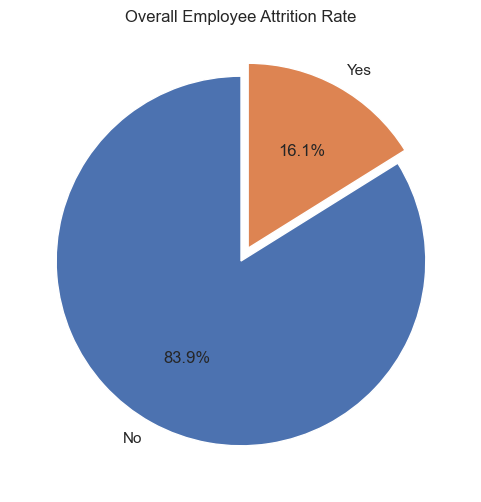

In [12]:
plt.figure(figsize=(6,6))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90, explode=(0, 0.08))
plt.title('Overall Employee Attrition Rate')
plt.show()

**Interpretation:** Roughly 1 in 6 employees at ABC Manufacturing Ltd has left the company. While the majority of staff stay, a 16% attrition rate is still a meaningful cost driver for HR and warrants deeper investigation into the departments, roles, and conditions where attrition concentrates.

### Chart 2 (Bar Chart) - Attrition Rate by Department

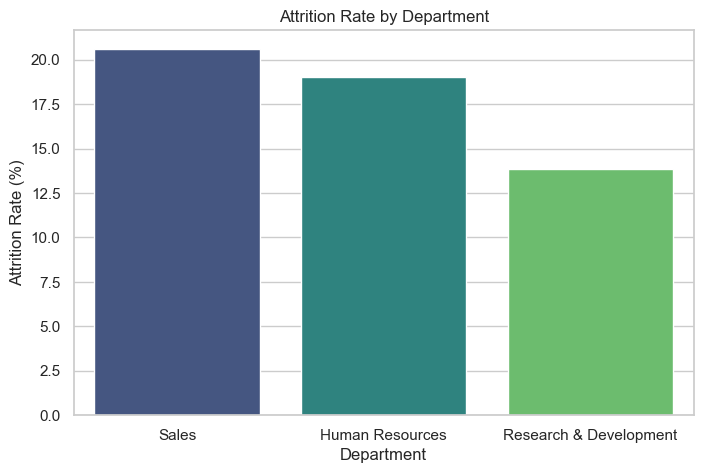

In [13]:
dept_attr = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure()
sns.barplot(x=dept_attr.index, y=dept_attr.values, hue=dept_attr.index, palette='viridis', legend=False)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.title('Attrition Rate by Department')
plt.show()

**Interpretation:** Sales has the highest attrition rate (20.6%), followed closely by Human Resources (19.0%). Research & Development, the largest department by headcount (961 employees), has the lowest attrition rate (13.8%). This suggests attrition drivers may differ by function  e.g. sales targets/pressure vs. R&D job stability.

### Chart 3 (Bar Chart) - Attrition Rate by Job Role

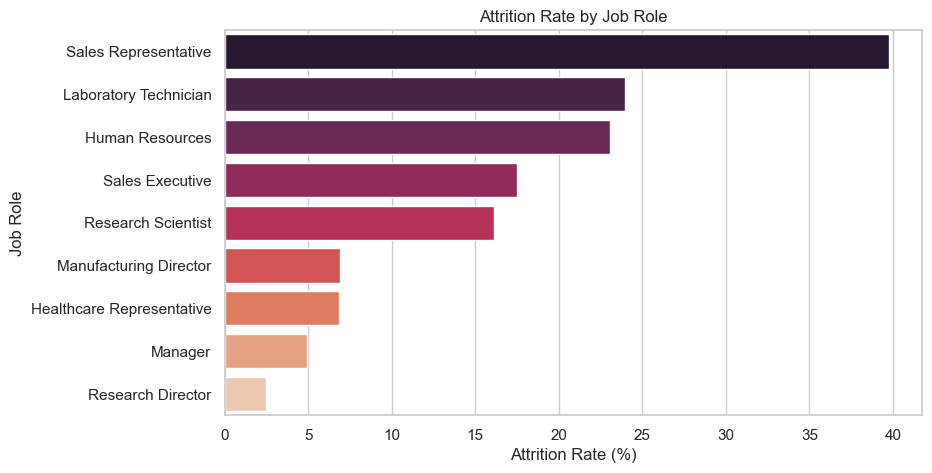

In [14]:
role_attr = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(9,5))
sns.barplot(x=role_attr.values, y=role_attr.index, hue=role_attr.index, palette='rocket', legend=False)
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.title('Attrition Rate by Job Role')
plt.show()

**Interpretation:** Sales Representatives have by far the highest attrition rate (39.8%), more than double the next closest role (Laboratory Technician, 23.9%). Research Directors and Managers have the lowest attrition (under 5%), roles typically associated with seniority, higher pay, and job security.

### Chart 4 (Bar Chart) - Attrition Rate by OverTime Status

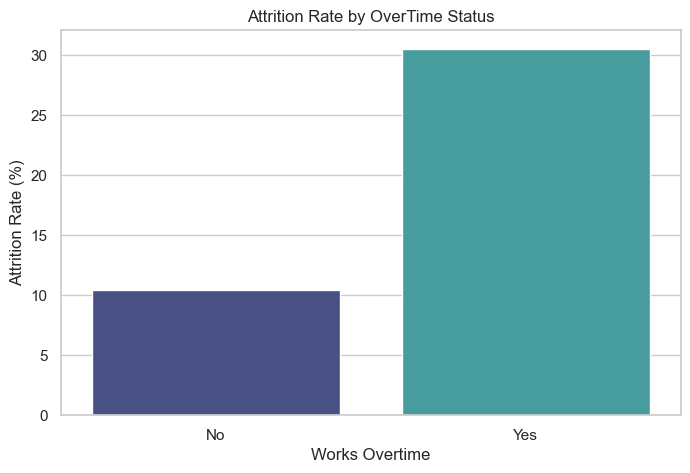

In [15]:
ot_attr = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
plt.figure()
sns.barplot(x=ot_attr.index, y=ot_attr.values, hue=ot_attr.index, palette='mako', legend=False)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Works Overtime')
plt.title('Attrition Rate by OverTime Status')
plt.show()

**Interpretation:** Employees who work overtime leave at nearly 3 times the rate of those who don't (30.5% vs 10.4%). This is one of the strongest single predictors of attrition in the dataset, pointing to potential burnout or work-life balance issues among overtime workers.

### Chart 5 (Histogram) - Age Distribution by Attrition

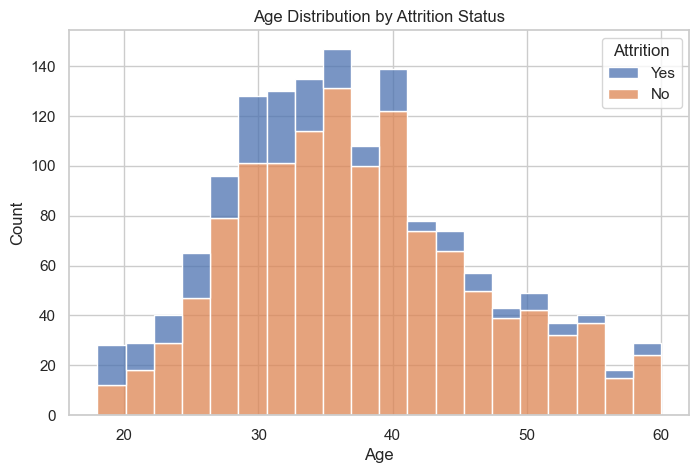

In [16]:
plt.figure()
sns.histplot(data=df, x='Age', hue='Attrition', multiple='stack', bins=20, palette=['#4C72B0', '#DD8452'])
plt.title('Age Distribution by Attrition Status')
plt.xlabel('Age')
plt.show()

**Interpretation:** Employees who leave skew younger (median age 32) than those who stay (median age 36). Attrition is concentrated among early-to-mid-career employees, likely reflecting greater external job mobility and fewer ties (family, tenure benefits) compared to older employees.

### Chart 6 (Histogram) - Monthly Income Distribution by Attrition

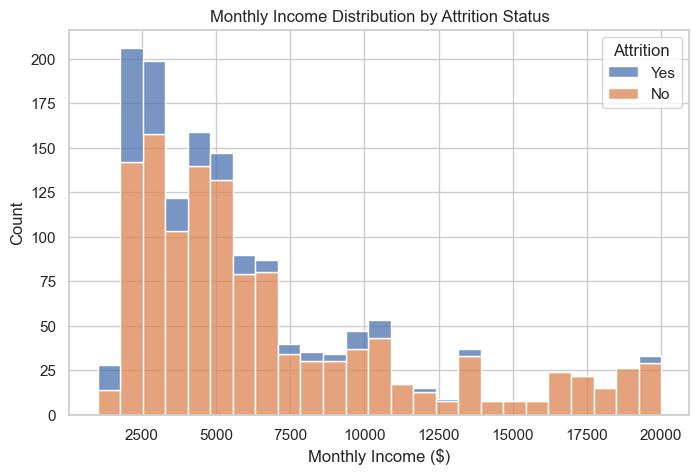

In [17]:
plt.figure()
sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', multiple='stack', bins=25, palette=['#4C72B0', '#DD8452'])
plt.title('Monthly Income Distribution by Attrition Status')
plt.xlabel('Monthly Income ($)')
plt.show()

**Interpretation:** Attrition is heavily concentrated in the lower income brackets (below ~$5,000/month). The median monthly income for employees who left ($3,202) is roughly 38% lower than for those who stayed ($5,204), suggesting compensation is a significant factor in retention.

### Chart 7 (Boxplot) — Monthly Income by Attrition

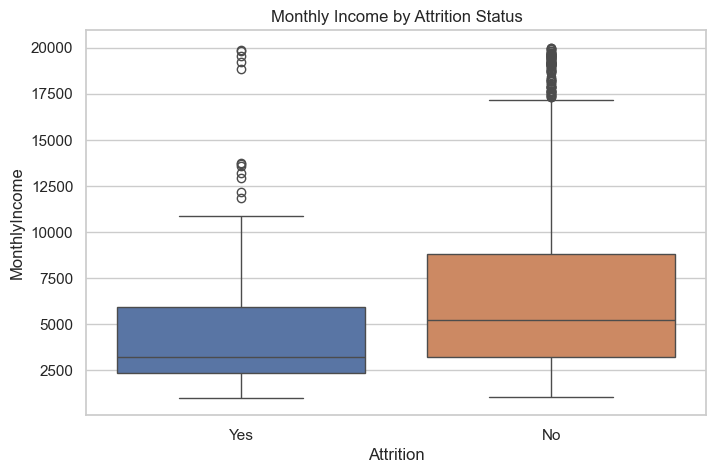

In [18]:
plt.figure()
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Monthly Income by Attrition Status')
plt.show()

**Interpretation:** The boxplot confirms a clear gap in the income distributions: the median, and the entire interquartile range, is lower for employees who left. There is also a long tail of high earners who stayed, reinforcing that income is protective against attrition.

### Chart 8 (Boxplot) — Age by Attrition

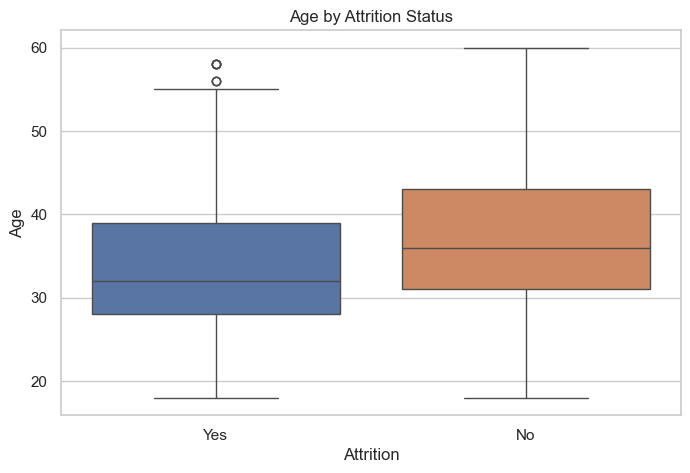

In [19]:
plt.figure()
sns.boxplot(data=df, x='Attrition', y='Age', hue='Attrition', palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Age by Attrition Status')
plt.show()

**Interpretation:** The age boxplot shows employees who left have a lower median age and a tighter, younger interquartile range, reinforcing the histogram finding that younger employees are more attrition-prone.

### Chart 9 (Bar Chart) - Attrition Rate by Marital Status

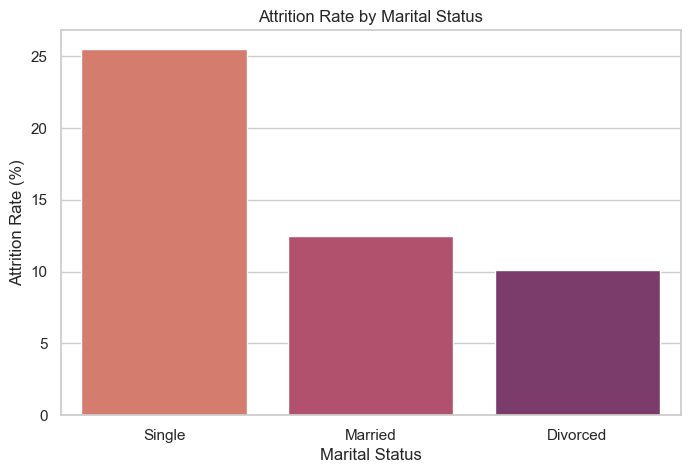

In [20]:
ms_attr = df.groupby('MaritalStatus')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
plt.figure()
sns.barplot(x=ms_attr.index, y=ms_attr.values, hue=ms_attr.index, palette='flare', legend=False)
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Marital Status')
plt.title('Attrition Rate by Marital Status')
plt.show()

**Interpretation:** Single employees have the highest attrition rate (25.5%), more than double that of married (12.5%) and divorced (10.1%) employees. This aligns with the age finding single employees are often younger and have fewer financial/family ties to a specific employer.

### Chart 10 (Bonus) - Correlation Heatmap of Numeric Features

In [21]:
df_num = df.copy()
df_num['AttritionFlag'] = (df_num['Attrition'] == 'Yes').astype(int)
numeric_cols = df_num.select_dtypes(include=[np.number]).columns
corr = df_num[numeric_cols].corr()['AttritionFlag'].sort_values(ascending=False)
corr.drop('AttritionFlag')

DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHours                    NaN
Name: AttritionFlag, dtype: float64

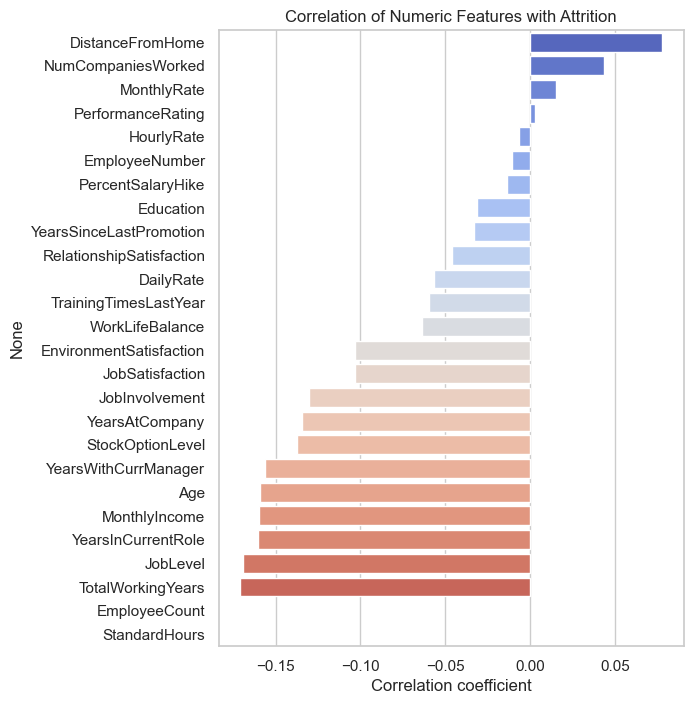

In [22]:
plt.figure(figsize=(6,8))
corr_plot = corr.drop('AttritionFlag')
sns.barplot(x=corr_plot.values, y=corr_plot.index, hue=corr_plot.index,
            palette='coolwarm', legend=False)
plt.title('Correlation of Numeric Features with Attrition')
plt.xlabel('Correlation coefficient')
plt.show()

**Interpretation:** `TotalWorkingYears`, `JobLevel`, `MonthlyIncome`, `Age`, and `YearsInCurrentRole` show the strongest negative correlation with attrition (i.e. more experienced, senior, better-paid, longer-tenured employees are less likely to leave). This gives an early indication of which variables are likely to be important for a future predictive model.

## Part 4 - Initial Business Insights

**Five Workforce Observations**
1. The workforce is relatively young and R&D-heavy: Research & Development accounts for 961 of 1,470 employees (65%), followed by Sales (446) and Human Resources (63).
2. Overall attrition stands at 16.1% (237 of 1,470 employees), consistent with, or slightly above, typical industry benchmarks (~10-15%).
3. The average employee is about 37 years old, has worked roughly 11.3 years in total, and has been with the company for 7 years.
4. Job satisfaction, environment satisfaction, and work-life balance are all rated on average around 2.7-2.8 out of 4, indicating a moderately, but not highly, satisfied workforce with room for improvement.
5. Compensation is highly variable: monthly income ranges from about \$1,009 to \$19,999, with a mean of ~\$6,503, reflecting a wide spread across job levels.

**Five Possible Factors Contributing to Attrition (with evidence)**
1. **Overtime** - employees working overtime leave at ~30.5% vs 10.4% for those who don't, the single strongest behavioural signal in the data.
2. **Low income** - median monthly income for leavers (\$3,202) is 38% lower than for stayers (\$5,204).
3. **Job role** - Sales Representatives (39.8%) and Laboratory Technicians (23.9%) show far higher attrition than Managers (4.9%) or Research Directors (2.5%).
4. **Younger age / early career** - leavers have a median age of 32 vs 36 for stayers, and single employees leave at more than double the rate of married employees (25.5% vs 12.5%).
5. **Department** - Sales (20.6%) and HR (19.0%) both show notably higher attrition than R&D (13.8%), suggesting department-specific working conditions or career paths matter.

## Answers to the Business Questions

1. **What does the company's workforce look like?** Predominantly R&D staff (65%), average age ~37, average tenure 7 years, moderate satisfaction scores (~2.7/4 average).
2. **Which departments have the highest employee attrition?** Sales (20.6%), followed by HR (19.0%); R&D is lowest (13.8%).
3. **Does age influence attrition?** Yes leavers are younger on average (32 vs 36 median), and attrition decreases as age increases.
4. **Does monthly income affect retention?** Yes  leavers earn a median of \$3,202/month vs \$5,204 for those who stay, a 38% gap.
5. **Does overtime influence attrition?** Yes, substantially 30.5% attrition among overtime workers vs 10.4% among non-overtime workers.
6. **Which job roles experience the highest turnover?** Sales Representative (39.8%) and Laboratory Technician (23.9%) are the highest-risk roles.
7. **Which variables appear important for future predictive modelling?** Based on correlation analysis, `OverTime`, `MonthlyIncome`, `Age`, `TotalWorkingYears`, `JobLevel`, `JobRole`, `MaritalStatus`, and `YearsInCurrentRole` all show meaningful relationships with attrition and are strong candidates for a future predictive model.